# Lab Instructions

You are working as an analyst for a consulting agency that has been hired to study and improve productivity at a mid-sized company.  Morale is very low and, after speaking with employees, several common complaints kept coming up:

* New employees complained that more tenured employees were lazy and unproductive.
* More tenured employees complained that the newer employees didn't focus and were therefore unproductive.
* Managers were worried that remote workers might be less productive.
* In-person employees found it impossible to focus and be productive when their desk was in the open plan area.
* Many people said they had so much administrative work to do they could only be truly productive if they worked overtime.
* Everyone complained that there were too many meetings.

The consulting agency carefully collected data on a number of factors including number of years at the company, focus (higher is better), productivity (higher is better), department, meetings per week, and desk location can be found in Employee_productivity.csv.

1. Determine which feature - years at the company, hours worked, or focus - has the strongest linear relationship with productivity.  Show a visualization and calculate R-squared for all three relationships to justify your answer.

2. Build on that linear regression model to determine what other featuers also impact productivity. Using both visualzations and R-squared values, build a model that can predicts employee productivity at this company. Evaluate each feature in the dataset.

3. Write a short (a few sentences) summary of how the different factors in the data relate to employee productivity.  What recommendations would you make so that employees can be as productive as possible?

**For the purposes of this lab you MUST use the model building techniques we covered in class.  Failure to do so will automatically result in a 20 point deduction.  I really want you to think about what you are doing and not just paste what you get from ChatGPT (which will often NOT do the correct thing by default).**



In [1]:
import pandas as pd

df = pd.read_csv('Employee_productivity.csv')

df.head()

,HoursWorked,FocusScore,ProductivityScore,Department,YearsAtCompany,TeamMeetingsPerWeek,DeskLocation
0,42.4,6.3,3127.96,Engineering,17,0,Open Plan
1,34.0,7.2,4742.60,HR,8,6,Private Office
2,47.2,5.6,2044.73,Sales,15,3,Remote
3,38.4,9.0,5818.92,HR,5,6,Private Office
4,36.4,2.5,1841.31,Sales,9,6,Remote


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Employee_productivity.csv')

df.head()

,HoursWorked,FocusScore,ProductivityScore,Department,YearsAtCompany,TeamMeetingsPerWeek,DeskLocation
0,42.4,6.3,3127.96,Engineering,17,0,Open Plan
1,34.0,7.2,4742.60,HR,8,6,Private Office
2,47.2,5.6,2044.73,Sales,15,3,Remote
3,38.4,9.0,5818.92,HR,5,6,Private Office
4,36.4,2.5,1841.31,Sales,9,6,Remote


In [2]:
df.columns

Index(['HoursWorked', 'FocusScore', 'ProductivityScore', 'Department',
       'YearsAtCompany', 'TeamMeetingsPerWeek', 'DeskLocation'],
      dtype='object')

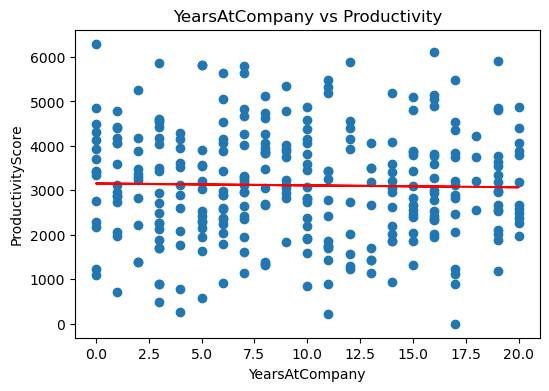

YearsAtCompany R² = 0.0004


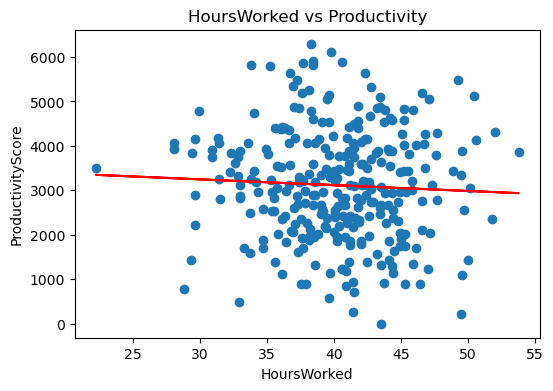

HoursWorked R² = 0.0026


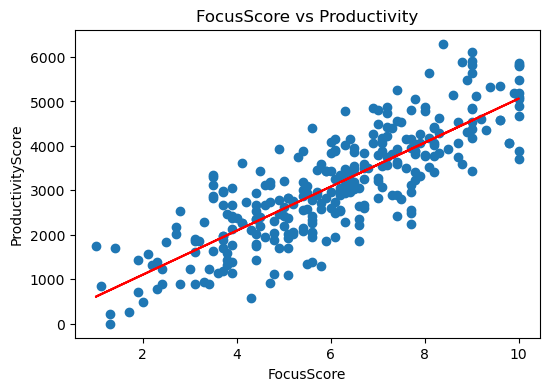

FocusScore R² = 0.6777


In [3]:
from sklearn.linear_model import LinearRegression

features = ['YearsAtCompany', 'HoursWorked', 'FocusScore']

for feature in features:

    X = df[[feature]]
    y = df['ProductivityScore']

    model = LinearRegression()
    model.fit(X, y)

    r2 = model.score(X, y)

    plt.figure(figsize=(6,4))
    plt.scatter(df[feature], y)
    plt.plot(df[feature], model.predict(X), color='red')
    plt.title(f'{feature} vs Productivity')
    plt.xlabel(feature)
    plt.ylabel('ProductivityScore')
    plt.show()

    print(feature, "R² =", round(r2,4))

In [4]:
import pandas as pd

df_encoded = pd.get_dummies(df, drop_first=True)

correlations = df_encoded.corr(numeric_only=True)['ProductivityScore']

print(correlations.sort_values(ascending=False))

ProductivityScore              1.000000
FocusScore                     0.823223
DeskLocation_Remote            0.080495
DeskLocation_Private Office    0.067297
Department_HR                  0.007688
Department_Sales              -0.012157
Department_Marketing          -0.018881
YearsAtCompany                -0.020286
HoursWorked                   -0.050990
TeamMeetingsPerWeek           -0.232905
Name: ProductivityScore, dtype: float64


Summary

The strongest predictor of employee productivity is FocusScore with an R² value of 0.6777, indicating a strong positive linear relationship. Employees with higher focus scores generally have higher productivity scores.

YearsAtCompany (R² = 0.0004) and HoursWorked (R² = 0.0026) have almost no linear relationship with productivity, suggesting that simply working longer hours or having more experience does not significantly improve productivity.

Additional analysis showed that TeamMeetingsPerWeek has a weak negative relationship with productivity, while Department and DeskLocation have very little impact.

Recommendation

The company should prioritize improving employee focus rather than increasing work hours or relying on employee tenure. Reducing unnecessary meetings and minimizing workplace distractions may help employees remain focused and improve productivity. Management should invest in strategies that increase focus, as this is the factor most strongly associated with higher productivity.